## Configuration

| Quantity | Value | Notes |
|---|---|---|
| Domain | $900 \times 600$ km | 50% longer in $x$ than $y$ |
| Resolution | $\Delta x = \Delta y = 10$ km | at the default `nj = 60` ($n_i = 90$) |
| Reduced gravity $g'$ | $0.08$ m $\text{s}^{-2}$ | gravity-wave speed $c_g=\sqrt{g'H}\approx 8$ m $s^{-1}$ |
| Layer thickness $H$ | $800$ m | |
| Coriolis $f_0$, $\beta$ | $10^{-4} \text{s}^{-1}$, $3\times 10^{-11}$ $\text{m}^{-1} \text{s}^{-1}$ | deformation radius $R_d=c_g/f_0\approx 80$ km |
| Bottom drag $\epsilon$ | $2.5\times10^{-5}$ m $\text{s}^{-1}$ | |
| Lateral viscosity $\nu_h$ | $200$ $\text{m}^2$ $\text{s}^{-1}$ | |

- **Jet target:** eastward, peak $1$ m $\text{s}^{-1}$, spanning $y/L_y \in [0.4, 0.6]$ (half-width
  $\sim 60$ km, comparable to $R_d$). Its free surface is set in geostrophic balance,
  $f\,u = -g'\,\partial_y\eta$, and used as the initial state everywhere.
- **Sponge (forcing):** restores $u\to$ jet, $v\to 0$, $h\to$ balanced at rate
  $10^{-5}$ $\text{s}^{-1}$ over the westernmost $150$ km plus the outer $100$ km near each wall.
  The $\beta$ term arrests the largest meridional mode. The restoring is applied with a
  backward-Euler step (unconditionally stable). The rest of the domain is unforced.
- **Seed:** a small smooth Gaussian bump in $h$ perturbs the balanced state to trigger the
  instability.

The `nj`/`run_params` line in the next cell selects the resolution and run length; coarser
settings run fast and still capture the instability, finer ones resolve more eddies.

# Original Full Model

In [1]:
import sys
sys.path.insert(0, '../OSSWEM_helpers')
# sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from OSSWEM_obc_orlanski import SSWEM  # [OBC] use the OBC working copy (adds run_record_bc / run_replace_bc)

mesh: ni = 120  nj = 120
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 15.0
Res: Ld/dx = 8.0
Res: Ls/dx = 0.10416666666666667


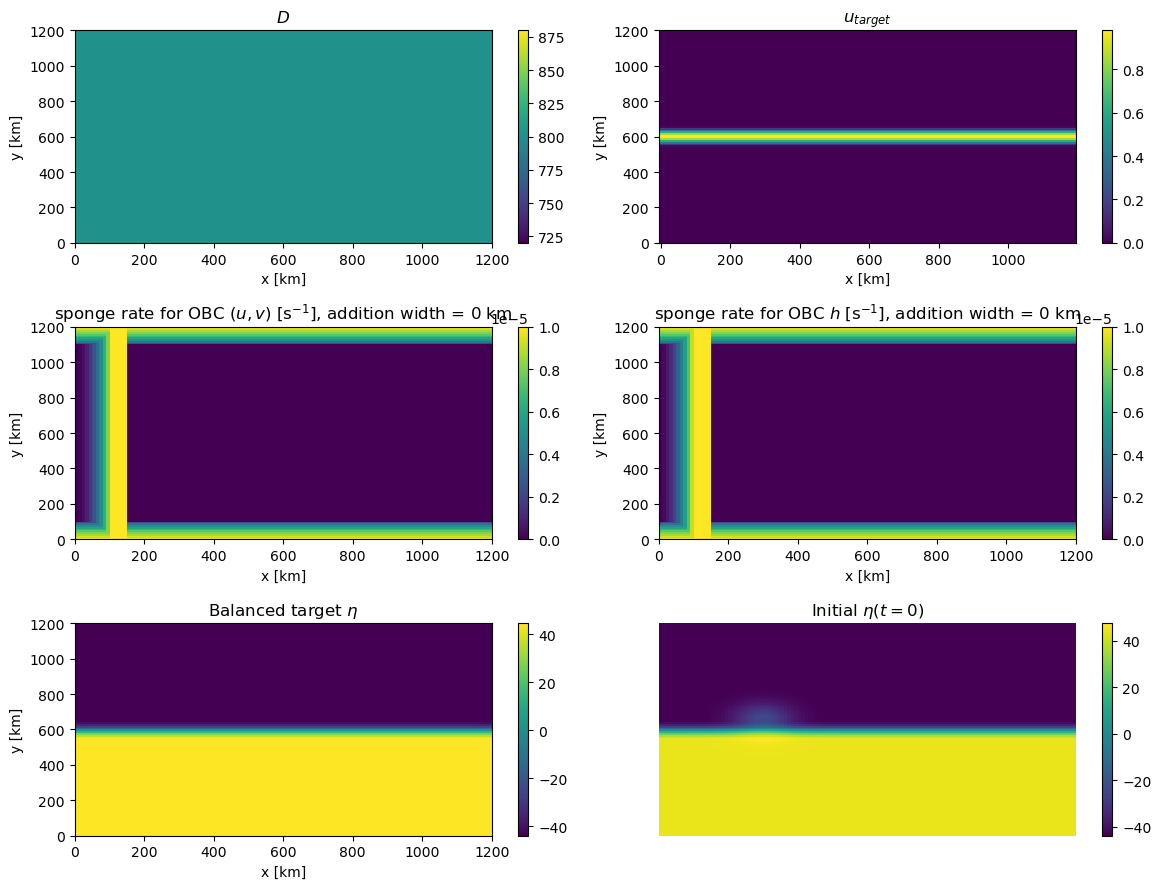

In [2]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 120, [200., 500, 100]  # Coarsest resolution with good instabilities
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

M = SSWEM(nj,
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          1200.e3,  # Domain width [m]  (50% longer in x than y)
          1.e-4,   # Coriolis [s-1]
          3.0e-11, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode)
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

# Target zonal jet and its geostrophically balanced free surface (f u = -g d(eta)/dy)
M.set_u_target_jet(1.0)                            # u_target = jet(y)

# Double jet
# yc = M.yu / M.Ly                                   # non-dim y at u-points
# hw = 60e3 / M.Ly                                   # half-width of each jet (< Ly/6 so they don't overlap)
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = 1.8 * (bump(2/5) + bump(3/5))                   # two eastward jets at y = 2Ly/5, 3Ly/5
# M.u_target = np.empty_like(M.u)
# for k in range(M.nk):
#     M.u_target[k, :] = 1.0 * profile               # 1.0 = peak speed [m/s]


uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=0.5): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
# rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 100e3

rate_h_ns = rate_h
rate_uv_ns = rate_uv

ratio_temp = 0
width = ratio_temp * Lw_uv
# width = 0.e3
# width = 50.e3 # The additional width of the sponge layer

# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Modified here, Lw + d
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

# Modified Sponge Layer
# M.u_relax  = rate_uv * np.maximum( 
#     np.maximum( (ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yu, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yu, M.Ly - yb, M.Ly)
#  )
# M.v_relax  = rate_uv * np.maximum( 
#     np.maximum( (ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yv, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yv, M.Ly - yb, M.Ly)
#  )
# M.h_relax  = rate_h * np.maximum( 
#     np.maximum((ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yh, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) 
# )
# M.h_target = hbal[None, :, :].copy()   


#====================================== END ======================================================

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 3.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate for OBC ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for OBC $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

In [3]:
# [OBC] Boundary columns + initial-condition snapshot (run AFTER the setup cell above).
# The easternmost columns of the WESTERN sponge define the prescribed boundary; the
# same i-index is used for u, v and h (all rows, all layers). We snapshot the IC so the
# second (replace) run can replay from an identical starting state.
n_bc    = 14                                                        # [OBC] number of boundary columns to store/replace (>=1; default 2)
i_edge  = np.where(M.xh1 < Lw_uv + width)[0].max()                 # [OBC] sponge eastern edge
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)                 # [OBC] the last n_bc columns
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},  '
      f"x = {np.round(M.xh1[west_cols]/1e3, 1)} km")

# [OBC] snapshot state + time + iter (iter matters: the continuity directional split
# [OBC] alternates on iter % 2, so Sim 2 must restart it from the same value).
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)          # [OBC]

[OBC] 14 boundary columns i = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],  x = [ 15.  25.  35.  45.  55.  65.  75.  85.  95. 105. 115. 125. 135. 145.] km


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


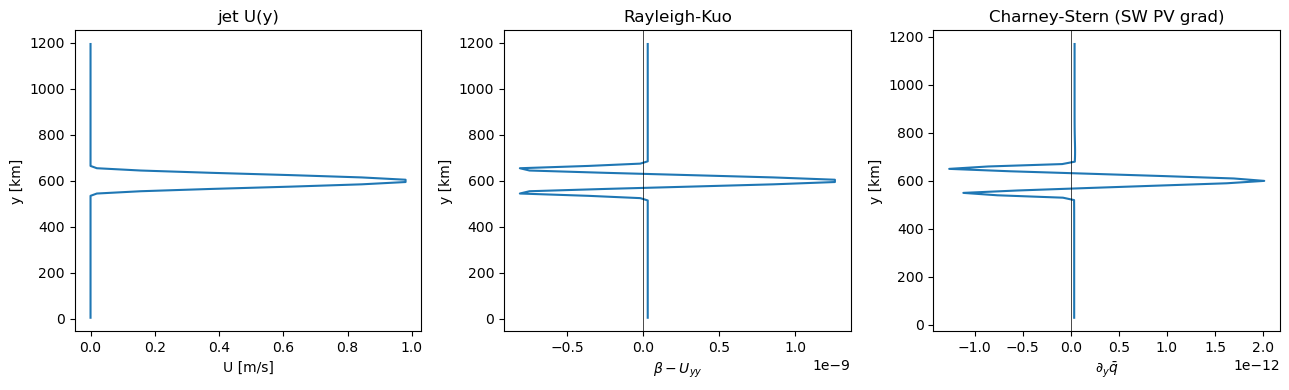

In [4]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

In [5]:
# Run the model — Sim 1: full simulation, recording (u,v,h) at the two boundary
# columns EVERY step (h at end-of-continuity, u/v at end-of-solve).  # [OBC]
# %time u,v,h,time = M.run(*run_params)                          # original (no recording)


# control where to store the downstream data
# probe_i0 = int(np.where(M.xh1 > 600e3)[0].min())   # [OBC]

# run with storing end of sponge layer
# %time u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(*run_params, west_cols, 
# st)  # [OBC]

# [OBC - Orlanski]
# The probe here was originally for storing downstream data for training, I will also store the downstream data for running an improved orlanski scheme. 

b_obc = M.ni - 1 - 20                          # [OBC - Orlanski] eastern OBC column (also set in the run cell)
ext_cols = np.array([b_obc + 1, b_obc + 2])    # [OBC - Orlanski] initialize the column stored for exterior of the orlanski open boundary
pres_cols = np.concatenate([west_cols])
# pres_cols = np.concatenate([west_cols, ext_cols]) 
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)

u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=True, probe_i0=b_obc - 2, n_probe = 3)   
# These are the columns for external forcing
h_ext_all = probe['h'][:, :, :, 2] # (nstep, nk, nj) -- column of the boundary, time series
v_ext_all = probe['v'][:, :, :, 2]
u_ext_all = probe['u'][:, :, :, 2]

# These are the columns for computing phase velocity for control run



# run with storing end of sponge layer + somewhere downstream. 
# %time u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(*run_params, west_cols, store_downstream=True, probe_i0=probe_i0, n_probe=2)  # [OBC]

numba threads = 16
CFL: dt*f = 0.027139999999999997
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 50000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 66.66666666666667
[OBC] recording (u,v,h) at boundary columns i = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 97..99
Running (record)...


MemoryError: Unable to allocate 641. MiB for an array with shape (50000, 1, 120, 14) and data type float64

In [ ]:
print(h_bc_all.shape)
print(pres_cols)
print(14 - 5 + 1 + 2)

(50000, 1, 120, 14)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
12


# Current vs Target Comparison

Here I compare the restored velocity field v.s. the target field. The purpose of introducing the sponge layer is to restore the field to the target field. This part is to exam the effect. 

In [ ]:
# # Find the index for the last column of the sponge layer
# i_edge = np.where(M.xh1 < Lw_uv + width)[0].max()
# x_edge = M.xh1[i_edge] / 1e3
# print(f'sponge last column: i = {i_edge},  x = {x_edge:.1f} km')

# # RMS over the meridional profile AT THAT ONE COLUMN, per output frame.
# # Skip the 3 dry wall rows at each end (h=0 there would distort the misfit).
# jj = slice(3, -3)
# def col_rms(field, target, i):
#     """field: (nt, nj, ni); target: (nj, ni). Returns a (nt,) time series of the
#     RMS of (field - target) over the interior rows of column i."""
#     d = field[:, jj, i] - target[jj, i]
#     return np.sqrt(np.mean(d**2, axis=-1))

# # 0 means first layer. 
# eta_target = M.h_target[0] - M.D     
# print(h.shape)                    
# h_mis = col_rms(h[:, 0, :, :] - M.D, eta_target, i_edge)     
# u_mis = col_rms(u[:, 0, :, :], M.u_target[0], i_edge)    
# v_mis = col_rms(v[:, 0, :, :], M.v_target[0], i_edge)    

# fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# ax[0].plot(time/86400, u_mis, label=r'$u-u_{targ}$')
# ax[0].plot(time/86400, v_mis, label=r'$v-v_{targ}$')
# ax[0].set_xlabel('time [days]'); ax[0].set_ylabel('RMS misfit [m/s]') 
# ax[0].set_title(f'velocity misfit at sponge edge'); ax[0].legend()
# ax[1].plot(time/86400, h_mis, color='C2', label=r'$\eta-\eta_{targ}$')
# ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('RMS misfit [m]')
# ax[1].set_title(f'thickness misfit at sponge edge (x={x_edge:.0f} km)'); ax[1].legend()
# fig.tight_layout()

# # --- Profile at that column: ANIMATE model (blue solid) vs target (black dashed) ---
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# import os

# y_km     = M.yh1 / 1e3
# u_tgt    = M.u_target[0, :, i_edge]            # static targets at the edge column
# v_tgt    = M.v_target[0, :, i_edge]            # (v target is 0 everywhere)
# eta_tgt  = eta_target[:, i_edge]
# u_prof   = u[:, 0, :, i_edge]                  # model profiles per frame, shape (nt, nj)
# v_prof   = v[:, 0, :, i_edge]
# eta_prof = (h[:, 0] - M.D)[:, :, i_edge]

# fig, ax = plt.subplots(1, 3, figsize=(13, 4))
# # u
# ax[0].plot(u_tgt, y_km, 'k--', label='target')
# (lu,) = ax[0].plot(u_prof[0], y_km, 'b-', label='model')
# ax[0].set_xlabel('u [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('u'); ax[0].legend()
# # v
# ax[1].plot(v_tgt, y_km, 'k--', label='target')
# (lv,) = ax[1].plot(v_prof[0], y_km, 'b-', label='model')
# ax[1].set_xlabel('v [m/s]'); ax[1].set_ylabel('y [km]'); ax[1].set_title('v'); ax[1].legend()
# # eta
# ax[2].plot(eta_tgt, y_km, 'k--', label='target')
# (le,) = ax[2].plot(eta_prof[0], y_km, 'b-', label='model')
# ax[2].set_xlabel(r'$\eta$ [m]'); ax[2].set_ylabel('y [km]'); ax[2].set_title(r'$\eta$'); ax[2].legend()

# # Fixed x-limits (over all frames + target) so the curves don't rescale each frame.
# def lims(*arrs):
#     lo = min(a.min() for a in arrs); hi = max(a.max() for a in arrs)
#     pad = 0.05 * (hi - lo + 1e-12)
#     return lo - pad, hi + pad
# ax[0].set_xlim(*lims(u_tgt,   u_prof))
# ax[1].set_xlim(*lims(v_tgt,   v_prof))
# ax[2].set_xlim(*lims(eta_tgt, eta_prof))

# sup = fig.suptitle('')
# fig.tight_layout()

# def update(n):
#     lu.set_xdata(u_prof[n])                    # only the model curves' x-data change
#     lv.set_xdata(v_prof[n])                    # (y_km, the vertical axis, stays fixed)
#     le.set_xdata(eta_prof[n])
#     sup.set_text(f'profiles at sponge edge (x={x_edge:.0f} km),  t = {time[n]/86400:.2f} days')
#     return lu, lv, le

# anim = FuncAnimation(fig, update, frames=len(time), interval=200)

# # Save the animation as a GIF in ./output, named by the sponge widths, rates + run_params.
# os.makedirs('output', exist_ok=True)
# dt, samp, nsamps = run_params                  # run_params = [dt, steps/segment, segments]
# gif_name = (f'sponge_profiles_Lw{Lw_uv/1e3:.0f}km_d{width/1e3:.0f}km'
#             f'_rh{rate_h:.0e}_ruv{rate_uv:.0e}'
#             f'_nj{nj}_dt{dt:.0f}_samp{samp}_seg{nsamps}.gif')
# gif_path = os.path.join('output', gif_name)
# # anim.save(gif_path, writer='pillow', fps=5)    # fps=5 matches interval=200 ms
# # print('saved', gif_path)

# plt.close(fig)
# HTML(anim.to_jshtml())


# Plots and Animations

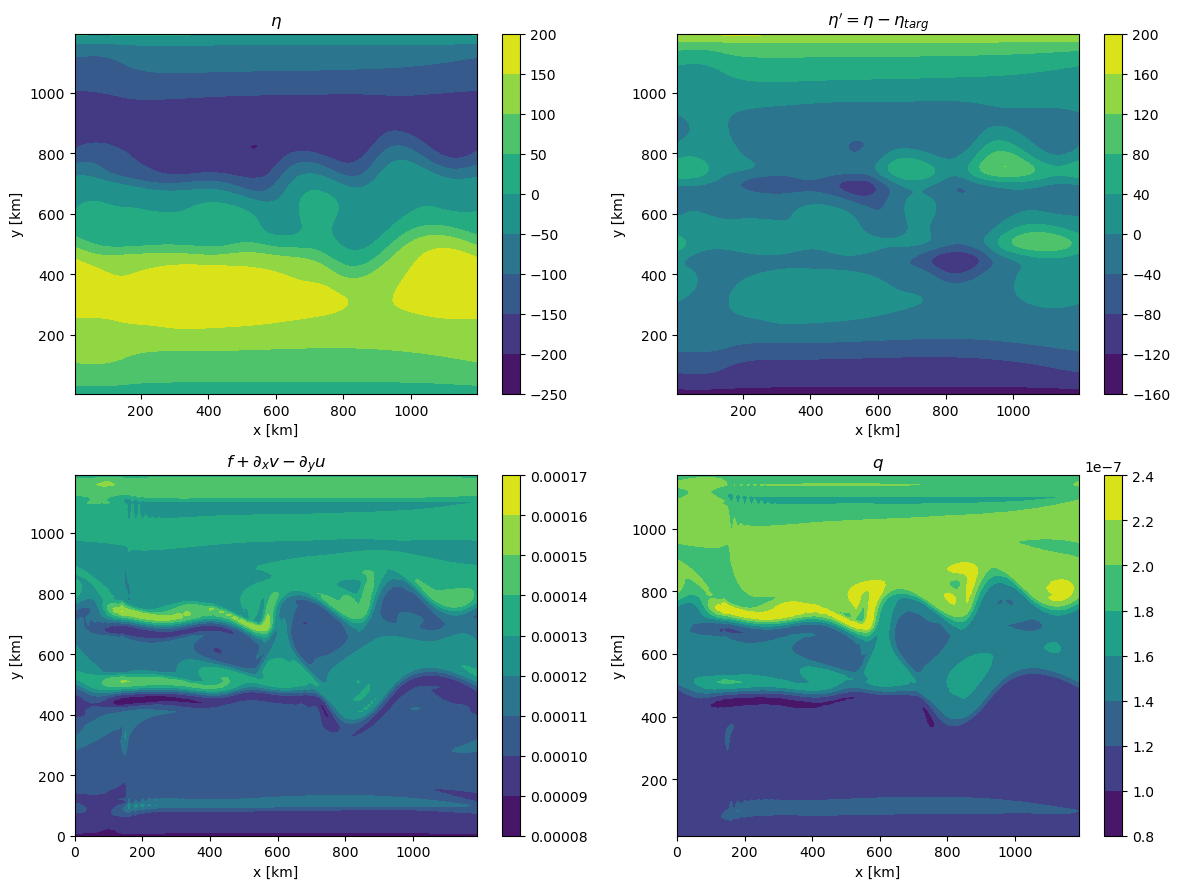

In [ ]:
# Snapshot
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
cs = axs[0,0].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=axs[0,0]); axs[0,0].set_title(r"$\eta$");
cs = axs[0,1].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) - (M.h_target[0] - M.D) ); fig.colorbar(cs, ax=axs[0,1]); axs[0,1].set_title(r"$\eta' = \eta - \eta_{targ}$");
cs = axs[1,0].contourf( M.xq1/1e3, M.yq1/1e3, M.abs_omega(k=0) ); fig.colorbar(cs, ax=axs[1,0]); axs[1,0].set_title(r'$f + \partial_x v - \partial_y u$');
cs = axs[1,1].contourf( M.xq1/1e3, M.yq1[2:-2]/1e3, M.q(h=h[-1], u=u[-1], v=v[-1], k=0)[2:-2,:] ); fig.colorbar(cs, ax=axs[1,1]); axs[1,1].set_title(r'$q$');
for a in axs.ravel():
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

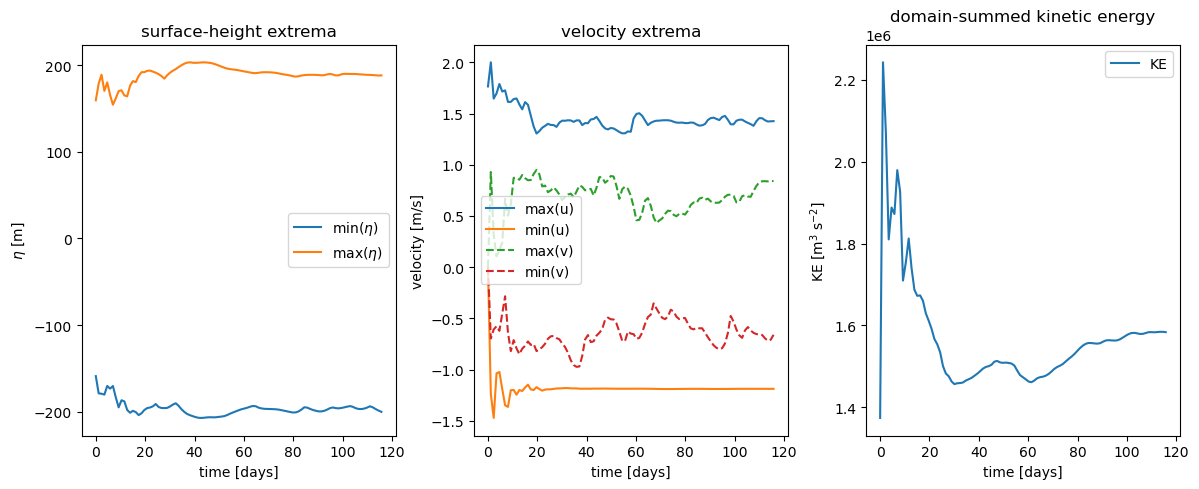

In [ ]:
# Plot time series
fig,ax = plt.subplots(1,3,figsize=(12,5))
ax[0].plot( time/86400, (h - M.D).min(axis=(1,2,3)), label=r'min($\eta$)' )
ax[0].plot( time/86400, (h - M.D).max(axis=(1,2,3)), label=r'max($\eta$)' )
ax[0].set_xlabel('time [days]'); ax[0].set_ylabel(r'$\eta$ [m]'); ax[0].set_title('surface-height extrema'); ax[0].legend();
ax[1].plot( time/86400, u.max(axis=(1,2,3)), label='max(u)' )
ax[1].plot( time/86400, u.min(axis=(1,2,3)), label='min(u)' )
ax[1].plot( time/86400, v.max(axis=(1,2,3)), '--', label='max(v)' )
ax[1].plot( time/86400, v.min(axis=(1,2,3)), '--', label='min(v)' )
ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('velocity [m/s]'); ax[1].set_title('velocity extrema'); ax[1].legend();
ax[2].plot( time/86400, M.KE(h=h, u=u, v=v).sum(axis=(1,2,3)), label='KE' )
ax[2].set_xlabel('time [days]'); ax[2].set_ylabel(r'KE [m$^3$ $\text{s}^{-2}$]'); ax[2].set_title('domain-summed kinetic energy'); ax[2].legend();
fig.tight_layout();

In [ ]:
# # Animate
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots()
# # Compute PV for all time levels
# pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))])
# # pv[:,:3,:] = 1e-7
# # pv[:,-2:,:] = 1e-7

# # Use consistent color limits across frames
# vmin, vmax = pv.min(), pv.max()
# cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=20, vmin=vmin, vmax=vmax)
# cb = fig.colorbar(cf)
# ax.axvline(150, color='k', ls=':', lw=1)              # sponge edge: free model is east of x=150 km
# ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
# title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

# def update(n):
#     ax.clear()
#     ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=20, vmin=vmin, vmax=vmax)
#     ax.axvline((Lw_uv +ratio_temp * Lw_uv)/1e3, color='k', ls=':', lw=1)          # sponge edge (ax.clear wipes it)
#     ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
#     ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

# anim = FuncAnimation(fig, update, frames=len(time), interval=100)
# anim.save('pv_evolution.gif', writer='pillow', fps=10, dpi=100)   # save GIF (no ffmpeg needed)
# plt.close(fig)
# HTML(anim.to_jshtml())

# OBC scaffolding: prescribed-boundary replay (Sim 2)

Sim 2 re-runs from the **same initial condition** with the sponge still active, but at
every step it overwrites the two boundary columns (`i = i_edge-1, i_edge`) with the
**stored** data from Sim 1 — `h` right after the continuity update, then `(u,v)` right
after the implicit Coriolis solve. Information thus enters the interior at that edge only
through the prescribed data.

Then an entire column downstream is also replaced by a Orlanski-Scheme like open boundary condition. 

The parameters for this run can be altered so that we could test the effect of the prescribed data. 

In [ ]:
# # Barotropic instability in a channel: a balanced zonal jet maintained by a
# # localized western sponge (beta-plane).

# # nj, ru_params = [dt, steps/segment, segments]
# # nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
# nj, run_params = 120, [200., 500, 100]  # Coarsest resolution with good instabilities
# # nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# # nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

# M = SSWEM(nj,
#           0.08,    # Gravity [m s-2]
#           800.,    # Nominal layer thickness [m]
#           1200.e3,  # Domain width [m]  (50% longer in x than y)
#           1.e-4,   # Coriolis [s-1]
#           3.0e-11, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode)
#           2.5e-5,  # Bottom drag rate [m s-1]
#           2e2,     # Lateral viscosity [m2 s-1]
#           nj=nj    # Rectangular channel
#           )
# # M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# # M.D[-1,:] = 0

# # Target zonal jet and its geostrophically balanced free surface (f u = -g d(eta)/dy)
# M.set_u_target_jet(1.0)                            # u_target = jet(y)
# uy  = M.u_target[0].mean(axis=1)                   # u(y)
# f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
# eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
# eta -= eta.mean() # Why remove mean? 
# hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
# hbal[0, :] = hbal[1, 1]
# hbal[-1, :] = hbal[-2, 1]

# Sponge Layer Setup

In [ ]:
# Rate for Northern and Southern boundary should be kept fixed

# Defualt
rate_h_w, rate_uv_w = 1.e-5, 1.e-5

# Smaller rate
# rate_h_w, rate_uv_w= 1.e-6, 1.e-6


# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Rebuild the sponge layer, only change the horizontal sponge. 
M.u_relax  = np.maximum( 
    np.maximum( rate_uv_w * ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), 
    rate_uv_ns * ramp(M.yu, M.Ly - yb, M.Ly) ), 
    rate_uv_ns * ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) 
    )

M.v_relax  = np.maximum( 
    np.maximum( rate_uv_w * ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), 
    rate_uv_ns * ramp(M.yv, M.Ly - yb, M.Ly) ), 
    rate_uv_ns * ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) 
    )

M.h_relax  = np.maximum( 
    np.maximum( rate_h_w * ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), 
    rate_h_ns * ramp(M.yh, M.Ly - yb, M.Ly) ), 
    rate_h_ns * ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) 
    )

M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

# Modified Sponge Layer
# M.u_relax  = rate_uv * np.maximum( 
#     np.maximum( (ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yu, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yu, M.Ly - yb, M.Ly)
#  )
# M.v_relax  = rate_uv * np.maximum( 
#     np.maximum( (ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yv, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yv, M.Ly - yb, M.Ly)
#  )
# M.h_relax  = rate_h * np.maximum( 
#     np.maximum((ramp2(M.xu, 0., Lw_uv) - ramp2(M.xu, width+ Lw_uv * (1 - 1 / factor), width + (2 - 1 / factor) * Lw_uv)) * (M.xu < Lw_uv + width), 
#     ramp(M.yh, M.Ly - yb, M.Ly) ), 
#     ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) 
# )
# M.h_target = hbal[None, :, :].copy()   

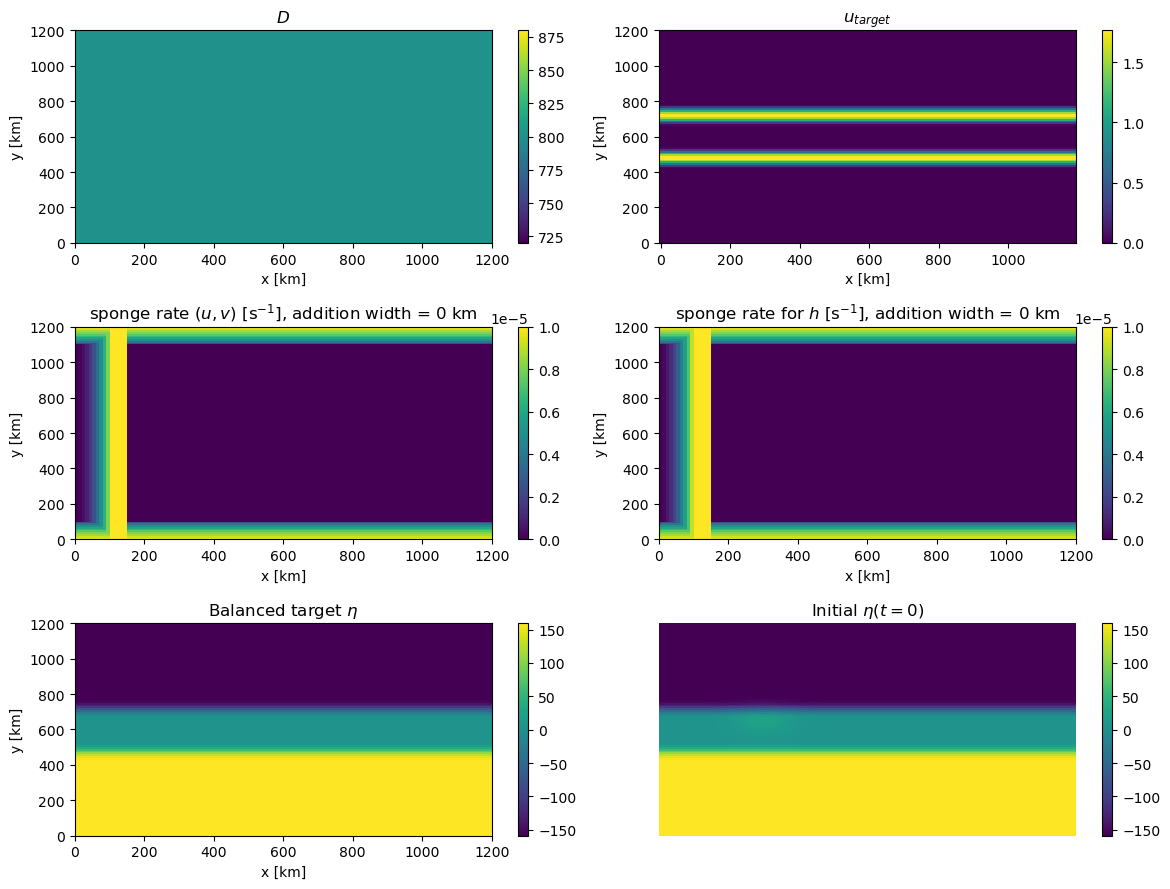

In [ ]:
# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 3.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

# Original Run with Prescribed Boundary Value

In [ ]:
# # [OBC] Sim 2 (replace): reset to the snapshotted IC, then run with the boundary
# # [OBC] columns overwritten by the stored data each step.
# M.u[:], M.v[:], M.h[:] = ic[0], ic[1], ic[2]      # [OBC] restore state
# M.time, M.iter = ic[3], ic[4]                      # [OBC] restore time/iter

# %time u2, v2, h2, time2, diffs = M.run_replace_bc(*run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all)  # [OBC]

# # [OBC] Sampled-snapshot agreement with Sim 1 (expected exactly 0.0).
# print('max|h2 - h| =', np.max(np.abs(h2 - h)))
# print('max|u2 - u| =', np.max(np.abs(u2 - u)))
# print('max|v2 - v| =', np.max(np.abs(v2 - v)))

In [ ]:
# # [OBC] Comparison results: per-step boundary misfit (free evolution vs stored) that is
# # [OBC] reported and then replaced at each step. Expected ~0 (machine epsilon / exactly 0).
# td = diffs['t_step'] / 86400.0
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# for key, lab in [('h_max', r'$h$'), ('u_max', r'$u$'), ('v_max', r'$v$')]:
#     ax[0].plot(td, diffs[key], label=lab)
# ax[0].set_xlabel('time [days]'); ax[0].set_ylabel('max |free - stored|')
# ax[0].set_title('OBC boundary misfit (max-abs)'); ax[0].legend()
# for key, lab in [('h_rms', r'$h$'), ('u_rms', r'$u$'), ('v_rms', r'$v$')]:
#     ax[1].plot(td, diffs[key], label=lab)
# ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('RMS |free - stored|')
# ax[1].set_title('OBC boundary misfit (RMS)'); ax[1].legend()
# fig.tight_layout()

# print('overall max boundary misfit:  '
#       f"h={diffs['h_max'].max():.3e}  u={diffs['u_max'].max():.3e}  v={diffs['v_max'].max():.3e}")

# Original Run with Prescribed West Boundary + Orlanski East Boundary

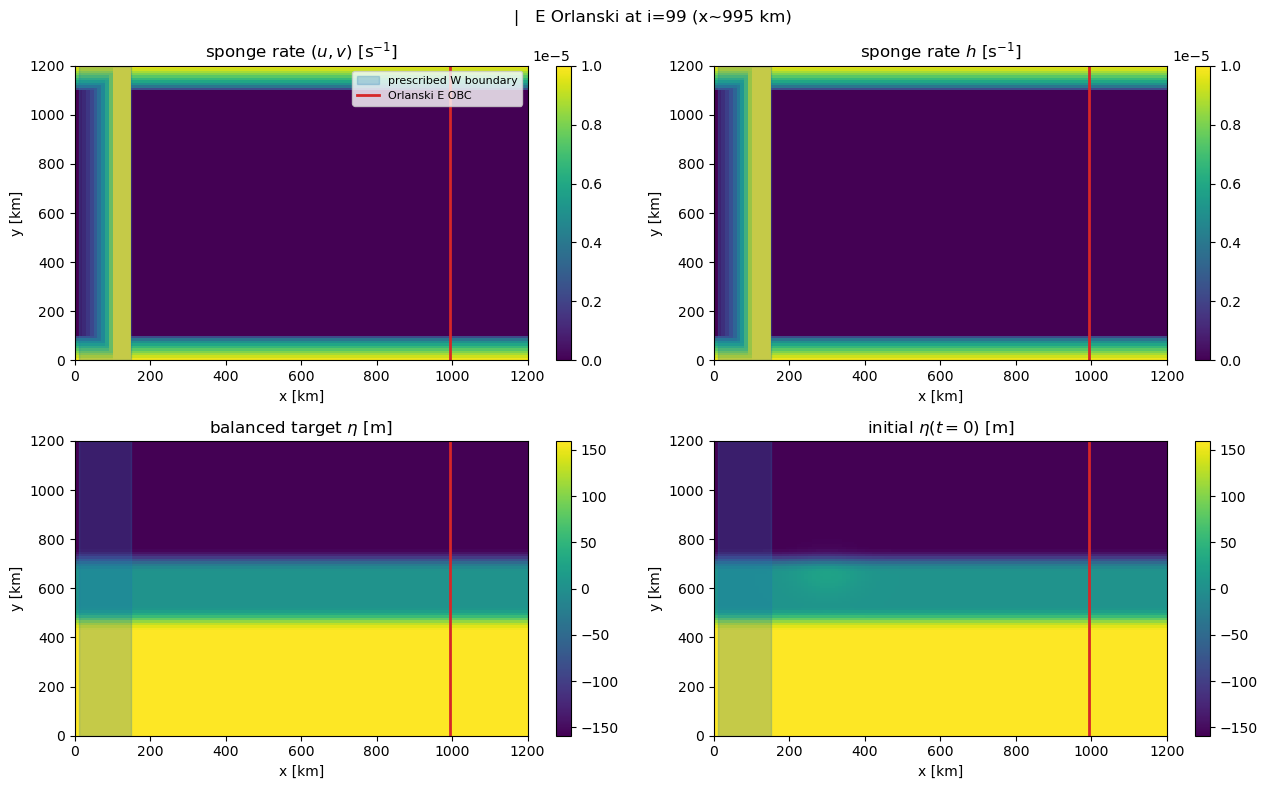

In [ ]:
# [OBC - Orlanski] Configuration check: sponge rates (u,v) and (h), the balanced target
# eta and the initial eta, with the prescribed WEST band (west_cols) and the Orlanski EAST
# OBC column (b_obc) marked on every panel.  (initial eta uses the IC snapshot `ic`, not
# the post-run state of M.)
# b_obc = M.ni - 1 - 20                          # [OBC - Orlanski] eastern OBC column (also set in the run cell)
x_km  = M.xh1 / 1e3
y_km  = M.yh1 / 1e3
dx_km = M.dx / 1e3
eta_init = ic[2][0] - M.D                 # initial eta from the IC snapshot
eta_targ = M.h_target[0] - M.D            # balanced target eta
xW0 = x_km[west_cols.min()] - dx_km / 2     # prescribed-W band edges [km]
xW1 = x_km[west_cols.max()] + dx_km / 2
xE  = x_km[b_obc]                         # Orlanski-E column [km]

def _mark(ax):
    ax.axvspan(xW0, xW1, color='tab:blue', alpha=0.25, label='prescribed W boundary')
    ax.axvline(xE, color='tab:red', lw=2, label='Orlanski E OBC')

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
p = ax[0,0].pcolormesh(x_km, y_km, M.u_relax[0]); fig.colorbar(p, ax=ax[0,0]); ax[0,0].set_title(r'sponge rate $(u,v)$ [s$^{-1}$]')
p = ax[0,1].pcolormesh(x_km, y_km, M.h_relax[0]); fig.colorbar(p, ax=ax[0,1]); ax[0,1].set_title(r'sponge rate $h$ [s$^{-1}$]')
p = ax[1,0].pcolormesh(x_km, y_km, eta_targ);     fig.colorbar(p, ax=ax[1,0]); ax[1,0].set_title(r'balanced target $\eta$ [m]')
p = ax[1,1].pcolormesh(x_km, y_km, eta_init);     fig.colorbar(p, ax=ax[1,1]); ax[1,1].set_title(r'initial $\eta(t{=}0)$ [m]')
for a in ax.ravel():
    _mark(a); a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
ax[0,0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'   |   E Orlanski at i={b_obc} (x~{xE:.0f} km)')
fig.tight_layout()

In [ ]:
M.u[:], M.v[:], M.h[:] = ic[0], ic[1], ic[2]      # restore IC
M.time, M.iter = ic[3], ic[4]
u3, v3, h3, time3, diff3, rx = M.run_obc(*run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc, h_ext_all = h_ext_all, u_ext_all = u_ext_all, v_ext_all = v_ext_all)

numba threads = 16
CFL: dt*f = 0.027139999999999997
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 50000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 66.66666666666667
...done
Mean r_x over run is h = 0.145u=0.090  v=0.084


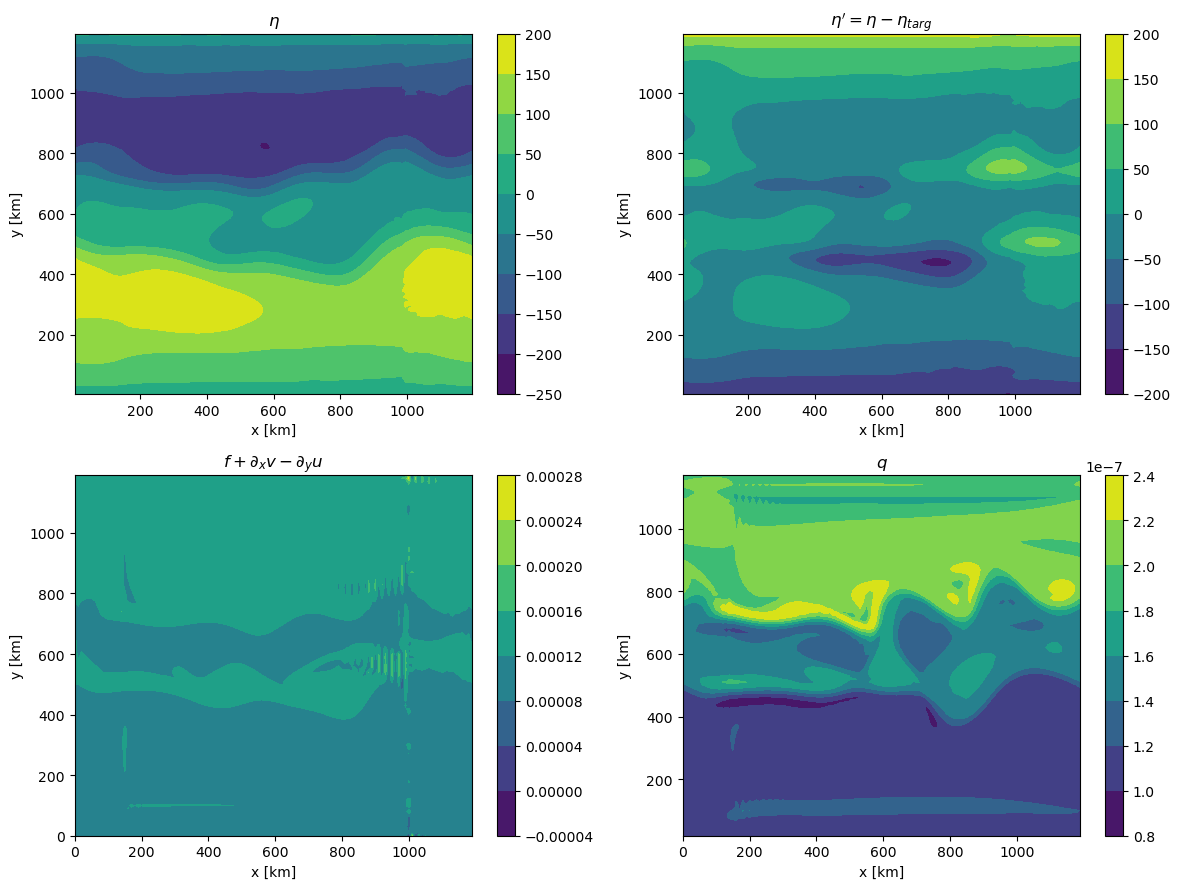

In [ ]:
# Snapshot
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
cs = axs[0,0].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=axs[0,0]); axs[0,0].set_title(r"$\eta$");
cs = axs[0,1].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) - (M.h_target[0] - M.D) ); fig.colorbar(cs, ax=axs[0,1]); axs[0,1].set_title(r"$\eta' = \eta - \eta_{targ}$");
cs = axs[1,0].contourf( M.xq1/1e3, M.yq1/1e3, M.abs_omega(k=0) ); fig.colorbar(cs, ax=axs[1,0]); axs[1,0].set_title(r'$f + \partial_x v - \partial_y u$');
cs = axs[1,1].contourf( M.xq1/1e3, M.yq1[2:-2]/1e3, M.q(h=h[-1], u=u[-1], v=v[-1], k=0)[2:-2,:] ); fig.colorbar(cs, ax=axs[1,1]); axs[1,1].set_title(r'$q$');
for a in axs.ravel():
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

# Sim 3 and Truch Comparision

Side-by-side PV animation of the three runs (original / prescribed-W / Orlanski-E) and
the misfit of $(u,v,\eta)$ at the OBC column. (The Sim 3 configuration is plotted above,
before the run.)

In [ ]:
# [OBC - Orlanski] PV (q) + zonal speed (u) comparison, 2 rows x 2 cols (animated):
#   row 0:  q   Sim1 original | Sim3 (prescribed-W + Orlanski-E, INTERIOR ONLY)
#   row 1:  u   Sim1 original | Sim3 (prescribed-W + Orlanski-E, INTERIOR ONLY)
# Sim3 is drawn only up to the open boundary (x <= b_obc); the exterior is dropped because
# it does not influence the interior. Sim1 is shown full as the reference.
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

nfr = min(len(time), len(time3))
pv1 = np.array([M.q(h=h[n],  u=u[n],  v=v[n],  k=0) for n in range(nfr)])   # Sim1 q  (nj, ni)
pv3 = np.array([M.q(h=h3[n], u=u3[n], v=v3[n], k=0) for n in range(nfr)])   # Sim3 q
u1f = u[:nfr, 0]                                                            # Sim1 u  (nfr, nj, ni)
u3f = u3[:nfr, 0]                                                           # Sim3 u

bcut = int(b_obc) + 1                                                       # keep columns 0..b_obc (drop the exterior)

# q colour range (from Sim1)
vmin, vmax = pv1.min(), pv1.max()
levels = np.linspace(vmin, vmax, 21)
norm   = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# u colour range (from Sim1), symmetric about 0 with a diverging map (u is signed)
uabs     = float(np.nanmax(np.abs(u1f)))
levels_u = np.linspace(-uabs, uabs, 21)
norm_u   = mpl.colors.Normalize(vmin=-uabs, vmax=uabs)
cmap_u   = 'RdBu_r'

x0_km = (Lw_uv + width) / 1e3
xq_km = M.xq1 / 1e3 - x0_km                                # x of q- and u-points (both on xq) [km]
yq_km = M.yq1 / 1e3
yh_km = M.yh1 / 1e3
xWban = (M.xh1[west_cols.max()] + M.dx/2) / 1e3 - x0_km
xEobc = M.xh1[b_obc] / 1e3 - x0_km

fig, axs = plt.subplots(2, 2, figsize=(13, 11))
for ax in axs[0]:
    fig.colorbar(mpl.cm.ScalarMappable(norm=norm), ax=ax, label=r'$q$ [s$^{-1}$ m$^{-1}$]')
for ax in axs[1]:
    fig.colorbar(mpl.cm.ScalarMappable(norm=norm_u, cmap=cmap_u), ax=ax, label=r'$u$ [m s$^{-1}$]')

def _draw(ax, x, y, Z, ttl, is_u=False):
    if is_u:
        ax.contourf(x, y, Z, levels=levels_u, norm=norm_u, cmap=cmap_u, extend='both')
    else:
        ax.contourf(x, y, Z, levels=levels, norm=norm, extend='both')
    ax.axvline(xWban, color='tab:blue', ls=':',  lw=1.0)
    ax.axvline(xEobc, color='tab:red',  ls='--', lw=1.5)
    ax.set_xlabel('x - sponge edge [km]'); ax.set_ylabel('y [km]'); ax.set_title(ttl)

def update(n):
    for a in axs.ravel(): a.clear()
    td1 = time[n] / 86400.; td3 = time3[n] / 86400.
    _draw(axs[0,0], xq_km,         yq_km, pv1[n],            f'Sim1 $q$   t={td1:.1f} d')
    _draw(axs[0,1], xq_km[:bcut],  yq_km, pv3[n][:, :bcut],  f'Sim1+Orlanski-E $q$ (interior)   t={td3:.1f} d')
    _draw(axs[1,0], xq_km,         yh_km, u1f[n],            f'Sim1 $u$   t={td1:.1f} d', is_u=True)
    _draw(axs[1,1], xq_km[:bcut],  yh_km, u3f[n][:, :bcut],  f'Sim1+Orlanski-E $u$ (interior)   t={td3:.1f} d', is_u=True)
    for a in axs.ravel(): a.set_xlim(xq_km[0], xq_km[-1])    # shared x-range so all 4 panels align

anim = FuncAnimation(fig, update, frames=nfr, interval=100)
anim.save('pv_u_obc3_orlanski.gif', writer='pillow', fps=10, dpi=100)
plt.close(fig)
HTML(anim.to_jshtml())


Exception ignored in: <function WeakMethod.__new__.<locals>._cb at 0x000002622E9960E0>
Traceback (most recent call last):
  File "d:\Anaconda\envs\obc\lib\weakref.py", line 61, in _cb
    callback(self)
  File "d:\Anaconda\envs\obc\lib\site-packages\matplotlib\cbook.py", line 323, in _remove_proxy
    del self.callbacks[signal][cid]
KeyError: 'changed'
Exception ignored in: <function WeakMethod.__new__.<locals>._cb at 0x000002623D3ADCF0>
Traceback (most recent call last):
  File "d:\Anaconda\envs\obc\lib\weakref.py", line 61, in _cb
    callback(self)
  File "d:\Anaconda\envs\obc\lib\site-packages\matplotlib\cbook.py", line 323, in _remove_proxy
    del self.callbacks[signal][cid]
KeyError: 'changed'


run-mean c [m/s]:  Sim1  h=3.00  u=2.98  v=3.51   |   Sim3  h=7.32  u=4.46  v=4.33   |   cg=8.00


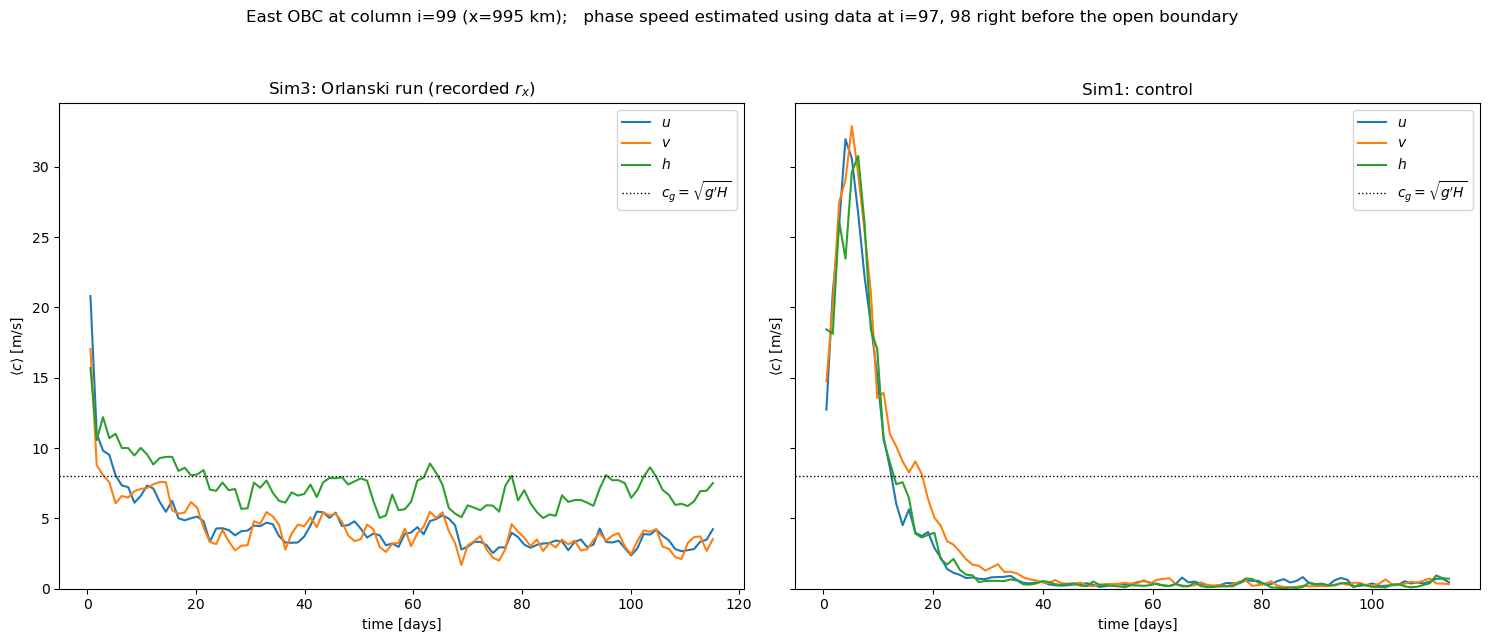

In [ ]:
# [OBC - Orlanski] Diagnose phase speeds at the eastern OBC -- Sim3 vs Sim1 control.
# Sim3: run_obc returned `rx`, the per-step Orlanski r_x = c*dt/dx, evaluated by the
#   scheme at column b_obc-1 from (b_obc-1, b_obc-2), clipped to [0,1], column mean.
# Sim1: SAME estimator at the SAME columns, evaluated offline from the per-step probe
#   (requires probe_i0 = b_obc-2, n_probe = 2 in the Sim-1 run cell).
# u,v,h should radiate at ~the same speed -> the three curves should track each other.
# NB: the column mean includes the clipped zeros (incoming/quiet rows), so levels are
#   biased low; read the curve shapes against each other and against cg.

assert list(probe['cols']) == [b_obc - 2, b_obc - 1, b_obc], \
    'probe must cover the estimator columns: set probe_i0=b_obc-2, n_probe=2 in the Sim-1 run cell and re-run'

dt    = run_params[0]
c_fac = M.dx / dt                                        # r_x -> phase speed [m/s]
cg    = np.sqrt(M.g[0] * M.D.max())                      # gravity-wave speed ~8 m/s
wblk  = int(run_params[1])                               # block window = 1 output segment

def block(a, w=wblk):                                    # NaN-safe block mean (Sim3 has NaNs after blow-up)
    a = np.where(np.isfinite(a), a, np.nan)
    return np.nanmean(a[:(len(a)//w)*w].reshape(-1, w), axis=1)

def rx_offline(phi):                                     # phi: probe array (nstep, nk, nj, 2) at (b-2, b-1)
    dpt = phi[1:, :, :, 1] - phi[:-1, :, :, 1]           # phi^{n+1} - phi^n          at b_obc-1
    dpx = phi[1:, :, :, 1] - phi[1:,  :, :, 0]           # phi_{b-1} - phi_{b-2}      at n+1
    r = np.where(dpx == 0., 0., -dpt / np.where(dpx == 0., 1., dpx))
    return np.clip(r, 0., 1.).mean(axis=(1, 2))          # same clip + column mean as the scheme

c1 = {k: c_fac * block(rx_offline(probe[k])) for k in 'huv'}   # Sim1 control, offline
c3 = {k: c_fac * block(rx[k + '_mean'])      for k in 'huv'}   # Sim3, recorded in-run
t1 = (np.arange(len(c1['h'])) + 0.5) * wblk * dt / 86400.
t3 = (np.arange(len(c3['h'])) + 0.5) * wblk * dt / 86400.

lim = [0., 1.05 * max(np.nanmax(list(c1.values())), np.nanmax(list(c3.values())), cg)]
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for k, col in [('u', 'C0'), ('v', 'C1'), ('h', 'C2')]:
    ax[0].plot(t3, c3[k], col, label=f'${k}$')
    ax[1].plot(t1, c1[k], col, label=f'${k}$')
for a, ttl in [(ax[0], 'Sim3: Orlanski run (recorded $r_x$)'),
               (ax[1], 'Sim1: control')]:
    a.axhline(cg, color='k', ls=':', lw=1, label=r"$c_g=\sqrt{g'H}$")
    a.set_ylim(lim); a.set_xlabel('time [days]')
    a.set_ylabel(r'$\langle c \rangle$ [m/s]'); a.set_title(ttl); a.legend()
fig.suptitle(f"East OBC at column i={int(b_obc)} (x={M.xh1[b_obc]/1e3:.0f} km);   "
             f"phase speed estimated using data at i={int(b_obc)-2}, {int(b_obc)-1} right before the open boundary "
             )
fig.tight_layout(rect=(0, 0, 1, 0.94))
print(f"run-mean c [m/s]:  Sim1  h={np.nanmean(c1['h']):.2f}  u={np.nanmean(c1['u']):.2f}  "
      f"v={np.nanmean(c1['v']):.2f}   |   Sim3  h={np.nanmean(c3['h']):.2f}  "
      f"u={np.nanmean(c3['u']):.2f}  v={np.nanmean(c3['v']):.2f}   |   cg={cg:.2f}")


49999 time-diff steps;  tblk=62 -> 806 time cols x 120 rows;  c_fac = dx/dt = 50.0 m/s,  cg = 8.00 m/s


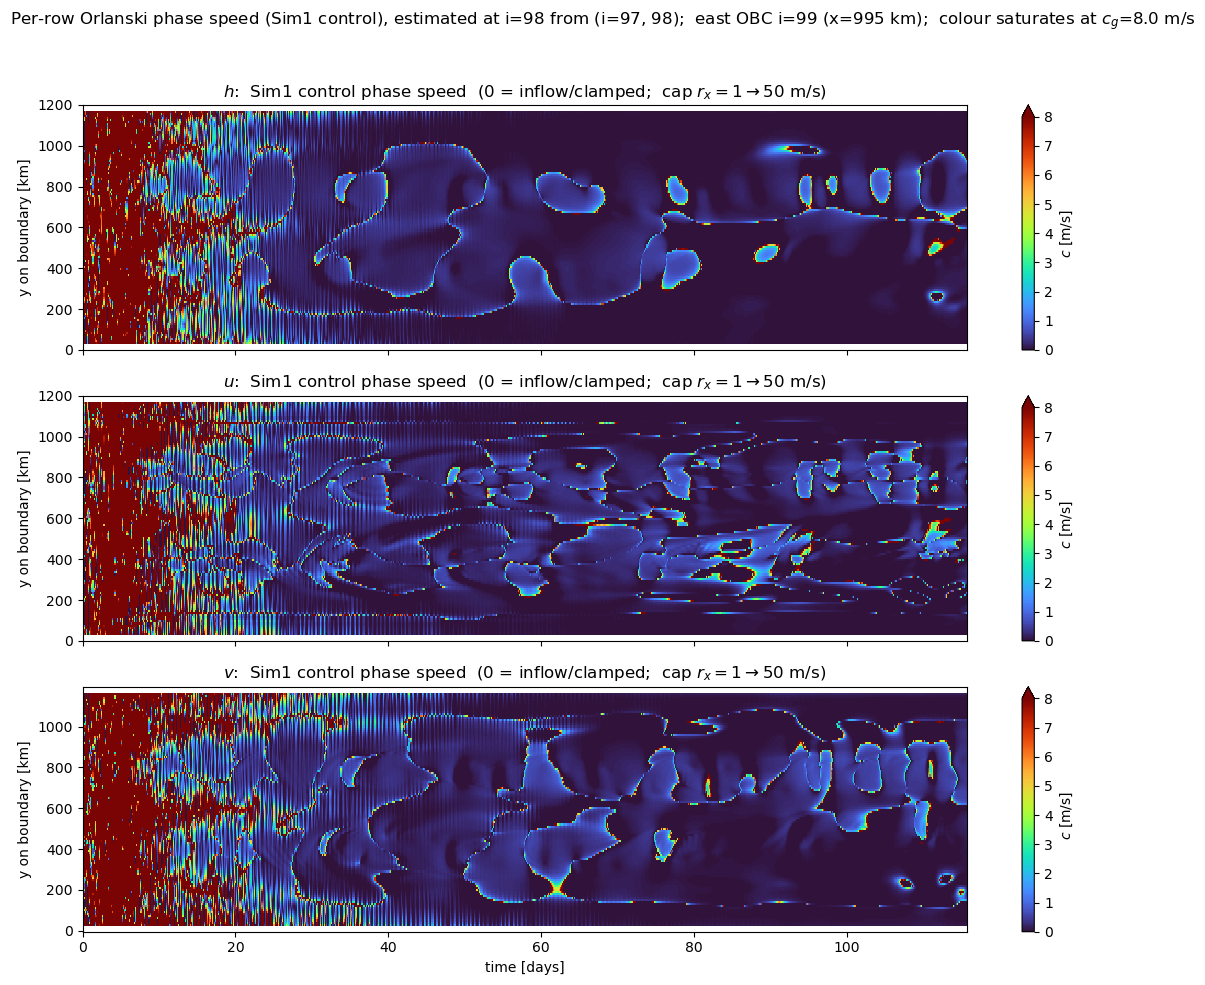

In [ ]:
# [OBC - Orlanski] Hovmoller of the per-row Orlanski phase speed of the CONTROL run (Sim1).
# x = time, y = location along the boundary, colour = phase speed c = r_x*dx/dt [m/s].
# Source = the Sim1 PROBE at columns [b_obc-2, b_obc-1, b_obc]. r_x is estimated AT column
# b_obc-1 from (b_obc-1, b_obc-2) -- the SAME column/estimator the scheme uses -- but kept
# PER ROW (no j-average, unlike cell 30) and clipped to [0,1]. One panel each for h, u, v.
import numpy as np, matplotlib.pyplot as plt

assert list(probe['cols']) == [b_obc - 2, b_obc - 1, b_obc], \
    'probe must cover [b_obc-2, b_obc-1, b_obc]: set probe_i0=b_obc-2, n_probe=3 in the Sim-1 cell'

k0    = 0                                                 # single layer
c_fac = M.dx / run_params[0]                              # r_x -> phase speed [m/s]  (= dx/dt)
cg    = np.sqrt(M.g[0] * M.D.max())                       # gravity-wave speed ~8 m/s
jmask = np.r_[0:3, M.nj - 3:M.nj]                         # dry N/S wall rows to blank

def rx_row(phi):                                          # phi: probe (nstep, nk, nj, 3) at (b-2, b-1, b)
    dpt = phi[1:, k0, :, 1] - phi[:-1, k0, :, 1]          # phi^{n+1}_{b-1} - phi^n_{b-1}   per row
    dpx = phi[1:, k0, :, 1] - phi[1:,  k0, :, 0]          # phi_{b-1} - phi_{b-2}  at n+1
    r = np.where(dpx == 0., 0., -dpt / np.where(dpx == 0., 1., dpx))
    return np.clip(r, 0., 1.)                             # (nstep-1, nj); same clip as _orlanski_east

T    = probe['h'].shape[0] - 1                            # number of time-difference steps
tblk = max(1, T // 800)                                   # time-block average (tblk=1 -> full res)
def tavg(c):
    n = (c.shape[0] // tblk) * tblk
    return c[:n].reshape(-1, tblk, c.shape[1]).mean(axis=1)

C = {k: tavg(c_fac * rx_row(probe[k])) for k in 'huv'}    # each (nblk, nj)
for k in C: C[k][:, jmask] = np.nan                       # blank the dry wall rows
t_days = (np.arange(C['h'].shape[0]) + 0.5) * tblk * run_params[0] / 86400.

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for a, k, yc in [(ax[0], 'h', M.yh1), (ax[1], 'u', M.yh1), (ax[2], 'v', M.yq1)]:
    pm = a.pcolormesh(t_days, yc / 1e3, C[k].T, vmin=0, vmax=cg, cmap='turbo', shading='auto')
    cb = fig.colorbar(pm, ax=a, extend='max'); cb.set_label(r'$c$ [m/s]')
    a.set_ylabel('y on boundary [km]')
    a.set_title(fr'${k}$:  Sim1 control phase speed  (0 = inflow/clamped;  '
                fr'cap $r_x{{=}}1 \to {c_fac:.0f}$ m/s)')
ax[-1].set_xlabel('time [days]')
fig.suptitle(f'Per-row Orlanski phase speed (Sim1 control), estimated at i={int(b_obc)-1} '
             f'from (i={int(b_obc)-2}, {int(b_obc)-1});  east OBC i={int(b_obc)} '
             f'(x={M.xh1[b_obc]/1e3:.0f} km);  colour saturates at $c_g$={cg:.1f} m/s')
fig.tight_layout(rect=(0, 0, 1, 0.96))
print(f'{T} time-diff steps;  tblk={tblk} -> {C["h"].shape[0]} time cols x {M.nj} rows;  '
      f'c_fac = dx/dt = {c_fac:.1f} m/s,  cg = {cg:.2f} m/s')


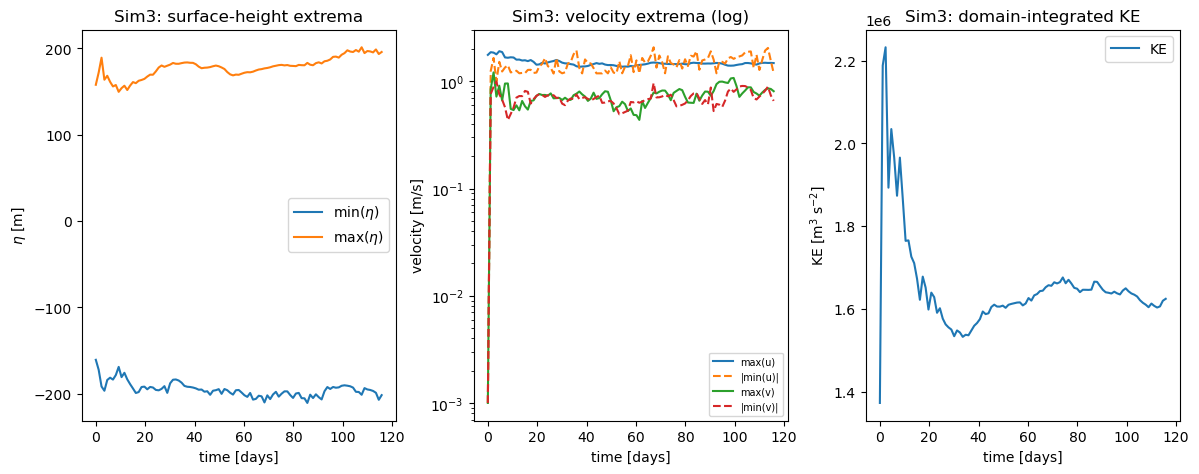

In [ ]:
n_valid = np.where(np.all(np.isfinite(u3), axis=(1,2,3)))[0]
n_end  = n_valid[-1] if len(n_valid) > 0 else len(time3) - 1
t3    = time3[:n_end+1] / 86400.0
h3f   = h3[:n_end+1]
u3f   = u3[:n_end+1]
v3f   = v3[:n_end+1]

fig,ax = plt.subplots(1,3,figsize=(12,5))
ax[0].plot( t3, (h3f - M.D).min(axis=(1,2,3)), label=r'min($\eta$)' )
ax[0].plot( t3, (h3f - M.D).max(axis=(1,2,3)), label=r'max($\eta$)' )
ax[0].set_xlabel('time [days]'); ax[0].set_ylabel(r'$\eta$ [m]'); ax[0].set_title('Sim3: surface-height extrema'); ax[0].legend();
ax[1].semilogy( t3, np.maximum(u3f.max(axis=(1,2,3)), 1e-3), label='max(u)' )
ax[1].semilogy( t3, np.maximum(np.abs(u3f.min(axis=(1,2,3))), 1e-3), '--', label='|min(u)|' )
ax[1].semilogy( t3, np.maximum(v3f.max(axis=(1,2,3)), 1e-3), label='max(v)' )
ax[1].semilogy( t3, np.maximum(np.abs(v3f.min(axis=(1,2,3))), 1e-3), '--', label='|min(v)|' )
ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('velocity [m/s]'); ax[1].set_title('Sim3: velocity extrema (log)'); ax[1].legend(fontsize=7);
ax[2].plot( t3, M.KE(h=h3f, u=u3f, v=v3f).sum(axis=(1,2,3)), label='KE' )
ax[2].set_xlabel('time [days]'); ax[2].set_ylabel(r'KE [m$^3$ s$^{-2}$]'); ax[2].set_title('Sim3: domain-integrated KE'); ax[2].legend();
fig.tight_layout();

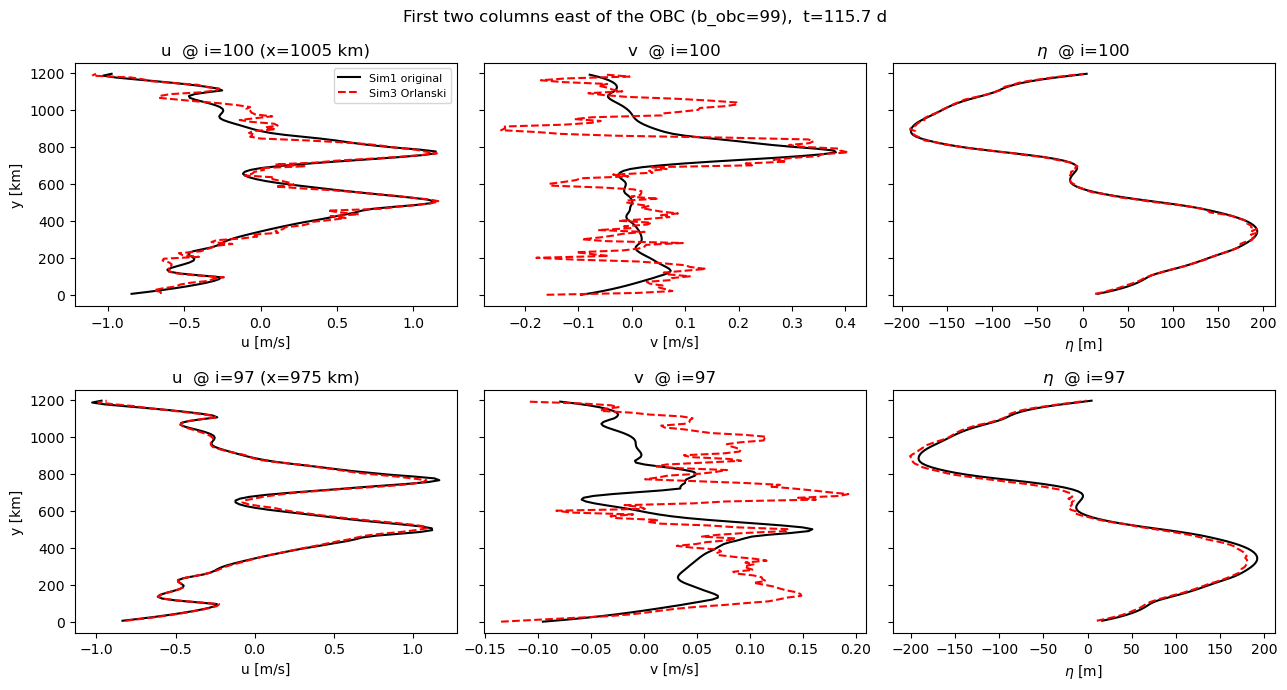

In [ ]:
# [OBC - Orlanski] First two columns EAST of the OBC (the red dashed line):
# i = b_obc+1, b_obc+2  (the prescribed "ghost" band). Sim1 (black) vs Sim3 (red), last frame.
# If the ghost prescribe is working, Sim3 should lie on top of Sim1 here.
import numpy as np, matplotlib.pyplot as plt

nf   = min(len(time), len(time3))-1       # last common output frame
cols = [int(b_obc) + 1, int(b_obc) - 2]        # first two columns east of the OBC
yh   = M.yh1 / 1e3                              # y of u/h points [km]
yq   = M.yq1 / 1e3                              # y of v points [km]
fig, ax = plt.subplots(len(cols), 3, figsize=(13, 7), sharey=True)
for r, c in enumerate(cols):
    xk = M.xh1[c] / 1e3
    ax[r,0].plot(u [nf,0,:,c], yh, 'k-',  label='Sim1 original')
    ax[r,0].plot(u3[nf,0,:,c], yh, 'r--', label='Sim3 Orlanski')
    ax[r,1].plot(v [nf,0,:,c], yq, 'k-');  ax[r,1].plot(v3[nf,0,:,c], yq, 'r--')
    ax[r,2].plot(h [nf,0,:,c] - M.D[:,c], yh, 'k-')
    ax[r,2].plot(h3[nf,0,:,c] - M.D[:,c], yh, 'r--')
    ax[r,0].set_title(f'u  @ i={c} (x={xk:.0f} km)'); ax[r,0].set_xlabel('u [m/s]'); ax[r,0].set_ylabel('y [km]')
    ax[r,1].set_title(f'v  @ i={c}');                 ax[r,1].set_xlabel('v [m/s]')
    ax[r,2].set_title(rf'$\eta$  @ i={c}');           ax[r,2].set_xlabel(r'$\eta$ [m]')
ax[0,0].legend(fontsize=8)
fig.suptitle(f'First two columns east of the OBC (b_obc={int(b_obc)}),  t={time3[nf]/86400:.1f} d')
fig.tight_layout()